# Prédiction de la consommation électrique — RNN/LSTM/GRU + MLP hybride

## Objectif

Ce notebook combine deux entrées de nature différente pour prédire la consommation électrique
des bâtiments **tout-électriques**  :

- une **entrée séquentielle** (consommation passée + météo horaire/journalière), encodée par un
  réseau récurrent (RNN simple, LSTM ou GRU — paramétrable, GRU par défaut) ;
- une **entrée statique** (métadonnées physiques du bâtiment : enveloppe thermique, occupation,
  gains solaires...), encodée par un MLP.

Les deux représentations sont concaténées puis passées dans une tête de régression commune.
C'est l'architecture dite *hybride séquence + tabulaire*.

Deux parties de prédiction sont traitées avec la même architecture :

1. **Partie A — Prévision à court terme (t+1)** : à partir d'une fenêtre glissante de 24 heures
   (consommation + météo), prédire la consommation de l'heure suivante. Beaucoup de données
   disponibles (chaque bâtiment fournit des milliers de fenêtres).
2. **Partie B — Extrapolation du total annuel** : à partir des 90 premiers jours observés
   (consommation + météo, au pas journalier), prédire la consommation électrique totale de
   l'année. Peu de données disponibles (une seule observation par bâtiment).

## Données et limite importante

Échantillon : les **100 bâtiments tout-électriques** déjà préparés dans
`timeseries_clustering_multi.ipynb` (`data/raw/timeseries_100_all_electric/`), avec leurs
features physiques .

**Pour la 2 ème partie B , N=100 bâtiments est un échantillon très petit** pour un réseau de neurones
(une seule ligne d'apprentissage par bâtiment, contre des milliers de fenêtres pour la 1 ere partie A).
Les métriques de test sur ~15 bâtiments doivent être lues avec prudence (forte variance). Étendre
l'échantillon de bâtiments tout-électriques serait la première piste d'amélioration si ces
résultats doivent être consolidés.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Bride TensorFlow (16 cœurs dispos par défaut) pour éviter la surchauffe/freeze pendant l'entraînement CPU
tf.config.threading.set_intra_op_parallelism_threads(6)
tf.config.threading.set_inter_op_parallelism_threads(2)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

ROOT = Path().resolve().parent.parent
DATA_RAW_100 = ROOT / "data" / "raw" / "timeseries_100_all_electric"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_RAW = ROOT / "data" / "raw"
FIGURES = ROOT / "reports" / "figures"

COL = "out.electricity.total.energy_consumption..kwh"
WEATHER_COLS = [
    "out.outdoor_air_drybulb_temp..c",
    "out.outdoor_air_relative_humidity..percentage",
    "out.outdoor_air_wetbulb_temp..c",
    "out.outdoor_humidity_ratio..kgwater_per_kgdryair",
    "out.weather.diffuse_solar_radiation..watt_per_m2",
    "out.weather.direct_normal_solar_radiation..watt_per_m2",
    "out.weather.wind_speed..meter_per_second",
]
SEQ_COLS = [COL] + WEATHER_COLS
N_SEQ_FEATURES = len(SEQ_COLS)

I0000 00:00:1786626005.180148  717790 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786626005.390822  717790 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786626006.851796  717790 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Chargement des 100 bâtiments : séries horaires + features statiques physiques

### Features statiques : agrégation physique de Boubaker

La branche statique (MLP) utilise les **5 agrégats physiques** définis  dans
`lgbm_electricity_5features.ipynb` (voir `reports/modele_enveloppe_thermique_5features.docx`
pour les formules), à la place de les propres indices d'enveloppe :

- **UA** — déperditions par transmission (murs, toit, plancher, fenêtres, portes)
- **H_ve** — déperditions par renouvellement d'air (infiltration)
- **C** — inertie thermique (classe ISO 13790 × surface plancher)
- **A_solaire** — surface solaire équivalente, pondérée par orientation des façades
- **compacité** — surface déperditive / volume

Le reste des features de `X_physical_engineered.parquet` (HVAC, occupation, électroménager,
climat, revenus...) est conservé — seuls les 4 indices d'enveloppe redondants avec les agrégats (`thermal_envelope_index`, `window_index`, `solar_gain_index`, `thermal_exposure`)
sont retirés, pour éviter le doublon d'information.

La fonction `build_aggregates` ci-dessous est reprise telle quelle du notebook `lgbm_electricity_5features.ipynb` . Elle
a été exécutée une fois sur les **549 971 logements** du dataset complet et le résultat sauvegardé
dans `data/processed/X_aggregates.parquet` (colonnes `bldg_id, UA, H_ve, C, A_solaire,
compacite`) — la cellule de chargement plus bas lit directement ce fichier plutôt que de
recalculer les agrégats à chaque exécution.

In [2]:
import re

FT2   = 0.0929     # ft² -> m²
RUS   = 0.1761     # R US -> R SI (m²K/W)
UUS   = 5.678      # U US -> U SI (W/m²K)
RFILM = 0.85       # films de surface (US), évite les U infinis
ISO   = dict(leger=110, moyen=165, lourd=260, tres_lourd=370)   # kJ/m²K (classes ISO 13790)

def _U(Rus):
    return 1.0 / ((np.maximum(Rus, 0) + RFILM) * RUS)

def _poids(az):
    az %= 360
    if 135 <= az <= 225:      # Sud
        return 1.0
    if az < 45 or az >= 315:  # Nord
        return 0.3
    return 0.6                 # Est / Ouest

def build_aggregates(Xs, Rs):
    """Xs = features encodées (X), Rs = colonnes out.params + matériaux (raw). Index alignés."""
    A_wall  = Rs['out.params.wall_area_above_grade_exterior..ft2'].values * FT2
    A_roof  = Rs['out.params.roof_area..ft2'].values                     * FT2
    A_floor = Rs['out.params.floor_area_lighting..ft2'].values           * FT2
    A_win   = Rs['out.params.window_area..ft2'].values                   * FT2
    A_door  = Rs['out.params.door_area..ft2'].values                     * FT2

    # 1) UA — déperditions par transmission (toiture routée via attic pour éviter le plafond fantôme)
    is_attic = Rs['in.geometry_attic_type'].astype(str).isin(['Vented Attic', 'Unvented Attic']).values
    R_top    = np.where(is_attic, Xs['in.insulation_ceiling'].values, Xs['in.insulation_roof'].values)
    UA = (_U(Xs['in.insulation_wall'].values) * A_wall
          + _U(R_top)                          * A_roof
          + _U(Xs['in.insulation_floor'].values) * A_floor
          + Xs['in.window_ufactor'].values * UUS * A_win
          + 1.14                                 * A_door)

    # 2) H_ve — déperditions par renouvellement d'air
    V    = A_floor * 2.5
    H_ve = 0.34 * (Xs['in.air_leakage_to_outside_ach50'].values / 20.0) * V

    # 3) C — inertie thermique (classe ISO 13790 × surface plancher)
    wt  = Rs['in.geometry_wall_type'].astype(str)
    fin = Rs['in.geometry_wall_exterior_finish'].astype(str)
    cls = np.select(
        [wt.str.contains('Concrete').values, fin.str.contains('Brick').values,
         (wt == 'Wood Frame').values, (wt == 'Steel Frame').values],
        [ISO['tres_lourd'], ISO['lourd'], ISO['leger'], ISO['moyen']], default=ISO['moyen'])
    C = cls * A_floor

    # 4) A_solaire — surface solaire équivalente (pondérée par orientation de chaque façade)
    shgc = Xs['in.window_shgc'].values
    ang  = np.degrees(np.arctan2(Xs['in.orientation_sin'].values,
                                 Xs['in.orientation_cos'].values)) % 360
    wa   = Rs['in.window_areas'].astype(str).values
    Asol = np.zeros(len(Xs))
    for i, (s, a, sh, aw) in enumerate(zip(wa, ang, shgc, A_win)):
        d = {'F': 0., 'B': 0., 'L': 0., 'R': 0.}
        for m in re.finditer(r'([FBLR])(\d+)', s):
            d[m.group(1)] = float(m.group(2))
        tot  = sum(d.values()) or 1.0
        dirs = {'F': a, 'R': a + 90, 'B': a + 180, 'L': a + 270}
        Asol[i] = sh * 0.9 * aw * sum((d[k] / tot) * _poids(dirs[k]) for k in d)

    # 5) compacité — surface déperditive / volume
    comp = (A_wall + A_roof + A_floor + A_win + A_door) / np.maximum(V, 1)

    return pd.DataFrame({'UA': UA, 'H_ve': H_ve, 'C': C, 'A_solaire': Asol, 'compacite': comp},
                        index=Xs.index)

In [3]:
parquet_files = sorted(DATA_RAW_100.glob("*-0.parquet"))
print(f"Bâtiments disponibles : {len(parquet_files)}")

bldg_ids = [int(f.stem.split("-")[0]) for f in parquet_files]

meta = pd.read_parquet(DATA_PROCESSED / "metadata_clean.parquet", columns=["bldg_id"])
pos = meta.reset_index(drop=False).set_index("bldg_id").loc[bldg_ids, "index"].values

# Features non-enveloppe (HVAC, occupation, électroménager, climat, revenus...) : X_physical_engineered,
# moins mes 4 indices d'enveloppe redondants avec les agrégats de Boubaker
ENVELOPE_IDX = ["in.thermal_envelope_index", "in.window_index", "in.solar_gain_index", "in.thermal_exposure"]
X_physical = pd.read_parquet(DATA_PROCESSED / "X_physical_engineered.parquet")
non_envelope = X_physical.drop(columns=ENVELOPE_IDX).iloc[pos].reset_index(drop=True)

# 5 agrégats physiques de Boubaker, précalculés (data/processed/X_aggregates.parquet)
agg_all = pd.read_parquet(DATA_PROCESSED / "X_aggregates.parquet").set_index("bldg_id")
boubaker_agg = agg_all.loc[bldg_ids].reset_index(drop=True)

static_df = pd.concat([non_envelope, boubaker_agg], axis=1)
static_all = static_df.astype("float32").values
N_STATIC_FEATURES = static_all.shape[1]

print(f"Features statiques : {static_all.shape} "
      f"({non_envelope.shape[1]} non-enveloppe + {boubaker_agg.shape[1]} agrégats de Boubaker)")
static_df.describe().round(2)

Bâtiments disponibles : 100


Features statiques : (100, 85) (80 non-enveloppe + 5 agrégats de Boubaker)


,in.aiannh_area,in.area_median_income,in.bedrooms,in.clothes_dryer_usage_level,in.cooling_setpoint,in.corridor,in.electric_panel_service_rating..a,in.electric_vehicle_charge_at_home,in.electric_vehicle_charger,in.electric_vehicle_miles_traveled,...,in.orientation,in.thermostat_flexibility,in.setpoint_shift_capacity,in.occupancy_intensity,in.dhw_intensity,UA,H_ve,C,A_solaire,compacite
count,100.0,100.00,100.00,100.00,100.00,100.0,100.00,100.00,100.0,100.00,...,100.00,100.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,0.02,0.96,3.18,0.98,22.30,0.0,189.85,0.83,0.0,8360.00,...,0.72,0.92,33.43,0.01,2.13,351.58,133.40,31871.56,4.85,1.20
std,0.14,0.45,0.81,0.14,1.97,0.0,28.44,0.27,0.0,5324.84,...,1.84,0.58,1.96,0.01,1.69,132.89,78.73,20620.31,2.52,0.15
min,0.0,0.15,1.00,0.80,15.60,0.0,90.00,0.09,0.0,1000.00,...,-2.36,0.0,27.80,0.00,0.00,134.93,27.83,6478.85,1.44,0.81
25%,0.0,0.70,3.00,0.80,21.10,0.0,200.00,0.89,0.0,3000.00,...,-0.79,1.0,32.20,0.01,0.90,247.52,89.09,18597.30,3.06,1.12
50%,0.0,0.90,3.00,1.00,22.20,0.0,200.00,0.89,0.0,7000.00,...,0.39,1.0,33.90,0.01,1.90,332.28,119.71,26027.79,4.24,1.23
75%,0.0,1.35,4.00,1.00,23.90,0.0,200.00,1.00,0.0,13000.00,...,2.36,1.0,34.50,0.02,3.00,422.66,163.16,36655.09,5.79,1.28
max,1.0,1.50,5.00,1.20,26.70,0.0,250.00,1.00,0.0,19000.00,...,3.14,2.0,35.60,0.05,7.70,842.30,435.10,148861.10,14.45,1.49


In [4]:
# Séries horaires (consommation + météo) pour les 100 bâtiments, pas horaire (8760 h/an)
agg = {COL: "sum", **{c: "mean" for c in WEATHER_COLS}}

hourly_all = []
for f in parquet_files:
    d = pd.read_parquet(f, columns=["timestamp"] + SEQ_COLS)
    d = d.assign(timestamp=lambda x: pd.to_datetime(x["timestamp"]) - pd.Timedelta("15m")).set_index("timestamp")
    d_h = d[SEQ_COLS].resample("h").agg(agg)
    hourly_all.append(d_h[SEQ_COLS].values.astype("float32"))

lengths = {len(h) for h in hourly_all}
assert lengths == {8760}, f"Longueurs incohérentes entre bâtiments : {lengths}"
hourly_all = np.stack(hourly_all, axis=0)  # (100, 8760, n_seq_features)
print("Séries horaires :", hourly_all.shape)

# Séries journalières dérivées (consommation sommée, météo moyennée par jour) — réutilisées
# pour la Partie B, sans relire les fichiers bruts
hourly_reshaped = hourly_all.reshape(100, 365, 24, N_SEQ_FEATURES)
daily_all = np.empty((100, 365, N_SEQ_FEATURES), dtype="float32")
daily_all[:, :, 0] = hourly_reshaped[:, :, :, 0].sum(axis=2)      # consommation : somme journalière
daily_all[:, :, 1:] = hourly_reshaped[:, :, :, 1:].mean(axis=2)   # météo : moyenne journalière
print("Séries journalières :", daily_all.shape)

Séries horaires : (100, 8760, 8)
Séries journalières : (100, 365, 8)


## Split train/val/test — au niveau bâtiment

Pour les deux partiees, le split se fait **par bâtiment** (70 train / 15 validation / 15 test), pas
par fenêtre temporelle : on teste ainsi la capacité du modèle à généraliser à des bâtiments
jamais vus, en s'appuyant uniquement sur leur fenêtre d'observation et leurs métadonnées
statiques. C'est plus exigeant qu'un split temporel intra-bâtiment, mais plus réaliste pour un
usage en diagnostic énergétique (prédire pour un nouveau logement).

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(100)
train_idx, val_idx, test_idx = perm[:70], perm[70:85], perm[85:]

print(f"Train : {len(train_idx)} bâtiments")
print(f"Val   : {len(val_idx)} bâtiments")
print(f"Test  : {len(test_idx)} bâtiments")

Train : 70 bâtiments
Val   : 15 bâtiments
Test  : 15 bâtiments


## Architecture hybride commune (réutilisée pour les deux parties)

`rnn_type` est paramétrable (`"SimpleRNN"`, `"LSTM"`, `"GRU"`) — GRU par défaut (bon compromis
rapidité/performance sur des séquences courtes).



L'idée générale
C'est une architecture "two-tower" / late fusion : deux réseaux traitent séparément deux types de données différents (une séquence temporelle et un vecteur de métadonnées), puis leurs représentations sont fusionnées avant la prédiction finale. C'est exactement le pattern utilisé quand tes features n'ont pas la même "forme" naturelle — ici une matrice (temps, capteurs) d'un côté, un vecteur plat de l'autre — et qu'on ne veut pas les forcer artificiellement dans une seule structure.



In [6]:
def build_hybrid_model(seq_len, n_seq_features, n_static_features,
                        rnn_type="GRU", rnn_units=32, static_units=(32, 16),
                        dropout=0.0):
    """Modèle hybride : branche séquentielle (RNN/LSTM/GRU) + branche statique (MLP),
    concaténées puis passées dans une tête de régression commune."""
    rnn_layer = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]

    seq_input = layers.Input(shape=(seq_len, n_seq_features), name="seq_input")
    x = rnn_layer(rnn_units)(seq_input)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    static_input = layers.Input(shape=(n_static_features,), name="static_input")
    s = static_input
    for units in static_units:
        s = layers.Dense(units, activation="relu")(s)
    if dropout > 0:
        s = layers.Dropout(dropout)(s)

    combined = layers.Concatenate()([x, s])
    combined = layers.Dense(max(8, rnn_units // 2), activation="relu")(combined)
    output = layers.Dense(1, name="output")(combined)

    return keras.Model(inputs=[seq_input, static_input], outputs=output, name=f"hybrid_{rnn_type}")

## Partie A — Prévision à court terme (t+1, fenêtre de 24h)

Fenêtre glissante de 24 heures (consommation + météo) → consommation de l'heure suivante.
Chaque bâtiment fournit `8760 - 24 = 8736` fenêtres, donc largement assez de données pour
entraîner un réseau récurrent malgré le faible nombre de bâtiments.

In [7]:
LOOKBACK = 24
WINDOW_STRIDE = 1  # cf. note ci-dessous : stride=1 nécessaire pour ne pas dégrader R²
                    # (testé stride=2 -> R² 0.88 -> 0.80). Le pic mémoire est maintenant réduit
                    # autrement (cf. cellule suivante) plutôt qu'en sous-échantillonnant les fenêtres.

def make_windows_t1(hourly_subset, stride=WINDOW_STRIDE):
    """Fenêtres glissantes (lookback, n_seq_features) -> consommation de l'heure suivante.
    Ne matérialise PLUS les features statiques répétées par fenêtre (cf. `WindowSequence` dans la
    cellule suivante) : seul un index de bâtiment (int32, quelques Mo) est renvoyé à la place — la
    version précédente (`np.repeat`) matérialisait à elle seule ~200 Mo pour le jeu d'entraînement
    (le warning TensorFlow "Allocation of 207916800 exceeds 10% of free system memory" plus bas
    dans ce notebook correspond exactement à cette taille : 611 520 x 85 x 4 octets)."""
    n_bldg, T, n_feat = hourly_subset.shape
    n_windows = T - LOOKBACK
    idx = np.arange(0, n_windows, stride)

    X = np.lib.stride_tricks.sliding_window_view(hourly_subset, LOOKBACK, axis=1)
    X = np.moveaxis(X[:, idx], -1, -2).reshape(-1, LOOKBACK, n_feat)

    y = hourly_subset[:, LOOKBACK + idx, 0].reshape(-1)                # cible à t+1
    persistence = hourly_subset[:, LOOKBACK - 1 + idx, 0].reshape(-1)  # dernière heure observée (baseline)
    bldg_idx = np.repeat(np.arange(n_bldg), len(idx)).astype("int32")

    return X, bldg_idx, y, persistence


Xa_train, ba_train, ya_train, _ = make_windows_t1(hourly_all[train_idx])
Xa_val, ba_val, ya_val, _ = make_windows_t1(hourly_all[val_idx])
Xa_test, ba_test, ya_test, persistence_pred = make_windows_t1(hourly_all[test_idx])

print(f"Train : {Xa_train.shape[0]:,} fenêtres")
print(f"Val   : {Xa_val.shape[0]:,} fenêtres")
print(f"Test  : {Xa_test.shape[0]:,} fenêtres")

Train : 611,520 fenêtres
Val   : 131,040 fenêtres
Test  : 131,040 fenêtres


In [8]:
# Normalisation : tous les scalers sont fités UNIQUEMENT sur le train.
# Xa_train/Xa_val/Xa_test sont réaffectés à leur propre version normalisée (au lieu d'une variable
# `_sc` séparée comme avant) : la version brute est ainsi libérée par le ramasse-miettes dès que la
# ligne suivante s'exécute, au lieu de rester en RAM à côté de sa version normalisée jusqu'à la fin
# de la Partie A (~650 Mo de doublon évitable, cf. les warnings TensorFlow "exceeds 10% of free
# system memory" enregistrés plus haut dans ce notebook).
seq_scaler_a = StandardScaler().fit(Xa_train.reshape(-1, N_SEQ_FEATURES))
Xa_train = seq_scaler_a.transform(Xa_train.reshape(-1, N_SEQ_FEATURES)).reshape(Xa_train.shape).astype("float32")
Xa_val = seq_scaler_a.transform(Xa_val.reshape(-1, N_SEQ_FEATURES)).reshape(Xa_val.shape).astype("float32")
Xa_test = seq_scaler_a.transform(Xa_test.reshape(-1, N_SEQ_FEATURES)).reshape(Xa_test.shape).astype("float32")

# Features statiques : une ligne par bâtiment (petit, quelques dizaines de Ko), PAS répétée par
# fenêtre (cf. `WindowSequence` ci-dessous qui fait le lien fenêtre -> bâtiment à la volée).
static_scaler_a = StandardScaler().fit(static_all[train_idx])
Sa_train_table = static_scaler_a.transform(static_all[train_idx]).astype("float32")
Sa_val_table = static_scaler_a.transform(static_all[val_idx]).astype("float32")
Sa_test_table = static_scaler_a.transform(static_all[test_idx]).astype("float32")

y_scaler_a = StandardScaler().fit(ya_train.reshape(-1, 1))
ya_train_sc = y_scaler_a.transform(ya_train.reshape(-1, 1)).astype("float32").ravel()
ya_val_sc = y_scaler_a.transform(ya_val.reshape(-1, 1)).astype("float32").ravel()


class WindowSequence(keras.utils.Sequence):
    """Assemble les batches (fenêtre séquentielle, features statiques[, cible]) à la volée : les
    features statiques sont récupérées par indexation de bâtiment au moment du batch
    (`static_table[bldg_idx[sel]]`, quelques Ko par batch) au lieu d'être matérialisées et
    répétées pour toutes les fenêtres à l'avance. `y=None` pour un usage predict-only."""

    def __init__(self, X, bldg_idx, y, static_table, batch_size, shuffle=False, seed=RANDOM_STATE):
        self.X, self.bldg_idx, self.y = X, bldg_idx, y
        self.static_table = static_table
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.order = np.arange(len(X))
        if shuffle:
            self.rng.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, i):
        sel = self.order[i * self.batch_size:(i + 1) * self.batch_size]
        x = (self.X[sel], self.static_table[self.bldg_idx[sel]])
        # (x,) et non x seul : Keras interprète un retour à 2 éléments comme (x, y), même quand x
        # est lui-même un tuple à 2 entrées -> ambigu sans cible, d'où l'empaquetage explicite.
        return (x,) if self.y is None else (x, self.y[sel])

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

In [9]:
model_a = build_hybrid_model(LOOKBACK, N_SEQ_FEATURES, N_STATIC_FEATURES, rnn_type="GRU", rnn_units=32)
model_a.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
model_a.summary()

early_stop_a = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

train_seq_a = WindowSequence(Xa_train, ba_train, ya_train_sc, Sa_train_table, batch_size=512, shuffle=True)
val_seq_a = WindowSequence(Xa_val, ba_val, ya_val_sc, Sa_val_table, batch_size=512, shuffle=False)

history_a = model_a.fit(
    train_seq_a,
    validation_data=val_seq_a,
    epochs=15, callbacks=[early_stop_a], verbose=1,
)

E0000 00:00:1786626019.106802  717790 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "hybrid_GRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static_input        │ (None, 85)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,752 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      4,032 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        784 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,113 (31.69 KB)

 Trainable params: 8,113 (31.69 KB)

...

1180/1195 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0780 - mae: 0.1583

1184/1195 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0780 - mae: 0.1583

1188/1195 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0780 - mae: 0.1583

1192/1195 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0780 - mae: 0.1583

1195/1195 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.0780 - mae: 0.1583 - val_loss: 0.0884 - val_mae: 0.1722


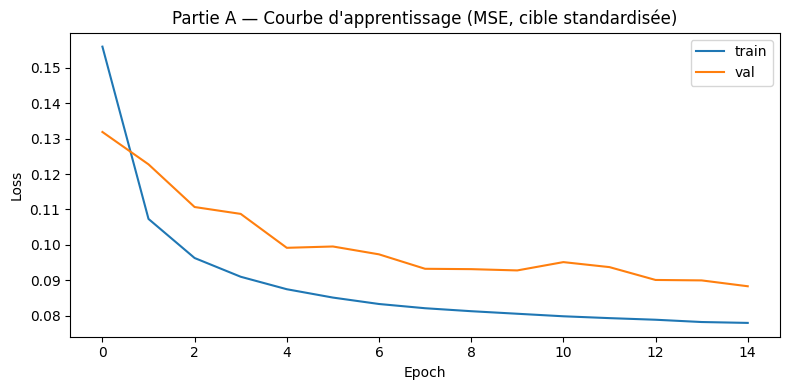

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history_a.history["loss"], label="train")
plt.plot(history_a.history["val_loss"], label="val")
plt.title("Partie A — Courbe d'apprentissage (MSE, cible standardisée)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_loss_modele_a_previsionhoraire.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
test_seq_a = WindowSequence(Xa_test, ba_test, None, Sa_test_table, batch_size=512, shuffle=False)
pred_test_a_sc = model_a.predict(test_seq_a, verbose=0)
pred_test_a = y_scaler_a.inverse_transform(pred_test_a_sc).ravel()

# Baseline de persistance : prédire la consommation de l'heure suivante = dernière heure observée
# (déjà calculée dans make_windows_t1, à partir des données brutes non normalisées)

def metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Modèle": label, "RMSE": rmse, "MAE": mae, "R2": r2}

df_metrics_a = pd.DataFrame([
    metrics(ya_test, persistence_pred, "Persistance (t = t-1)"),
    metrics(ya_test, pred_test_a, f"Hybride GRU+MLP ({LOOKBACK}h)"),
]).set_index("Modèle")

df_metrics_a.round(4)

,RMSE,MAE,R2
Modèle,,,
Persistance (t = t-1),1.1908,0.6439,0.8274
Hybride GRU+MLP (24h),1.0037,0.6369,0.8774


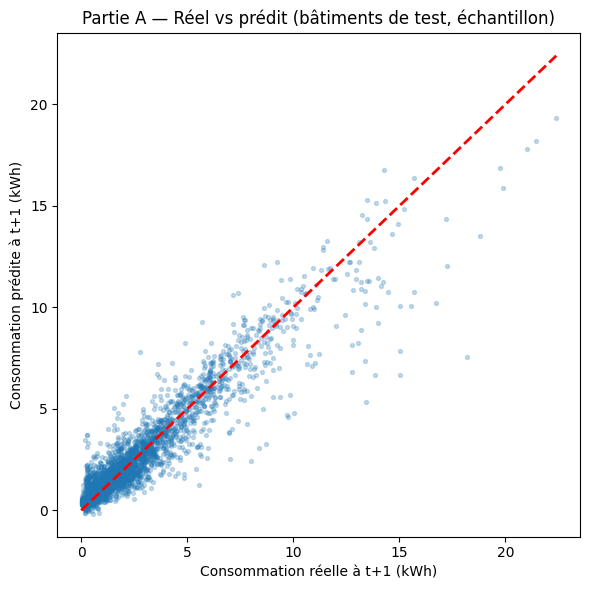

In [12]:
rng_plot = np.random.default_rng(RANDOM_STATE)
n_points = 3000
sample = rng_plot.choice(len(ya_test), size=min(n_points, len(ya_test)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ya_test[sample], pred_test_a[sample], alpha=0.25, s=8)
lim = [0, max(ya_test[sample].max(), pred_test_a[sample].max())]
ax.plot(lim, lim, "r--", linewidth=2)
ax.set_xlabel("Consommation réelle à t+1 (kWh)")
ax.set_ylabel("Consommation prédite à t+1 (kWh)")
ax.set_title("Partie A — Réel vs prédit (bâtiments de test, échantillon)")
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_tacheA_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

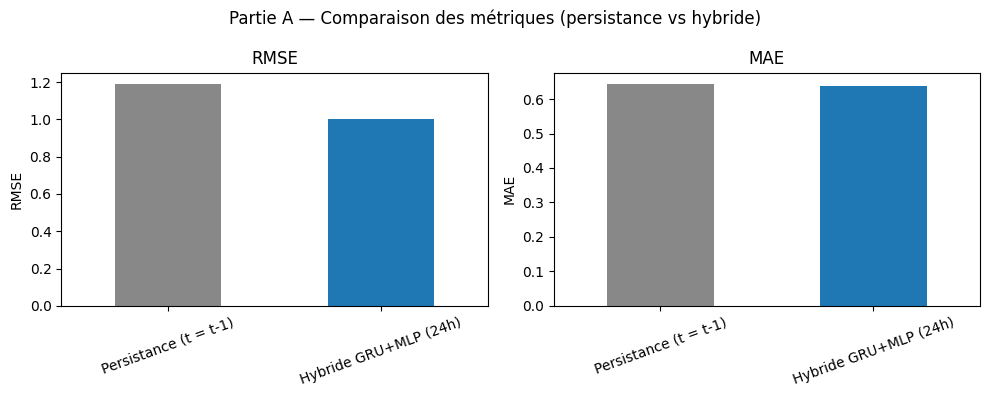

In [13]:
def plot_metrics_bar(df_metrics, title, filename):
    """Barres comparatives RMSE / MAE entre les modèles d'une table de métriques."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    colors = ["#888888", "#1f77b4", "#2ca02c"]
    for ax, metric in zip(axes, ["RMSE", "MAE"]):
        df_metrics[metric].plot(kind="bar", ax=ax, color=colors[: len(df_metrics)])
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_metrics_bar(
    df_metrics_a,
    "Partie A — Comparaison des métriques (persistance vs hybride)",
    "rnn_mlp_partieA_metrics_bar.png",
)

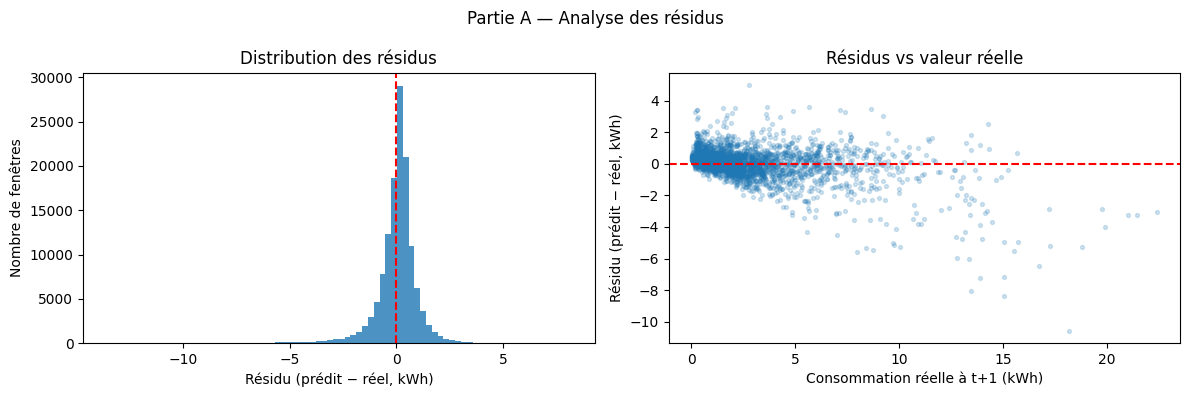

In [14]:
residuals_a = pred_test_a - ya_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals_a, bins=80, color="#1f77b4", alpha=0.8)
axes[0].axvline(0, color="r", linestyle="--")
axes[0].set_xlabel("Résidu (prédit − réel, kWh)")
axes[0].set_ylabel("Nombre de fenêtres")
axes[0].set_title("Distribution des résidus")

axes[1].scatter(ya_test[sample], residuals_a[sample], alpha=0.2, s=8)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Consommation réelle à t+1 (kWh)")
axes[1].set_ylabel("Résidu (prédit − réel, kWh)")
axes[1].set_title("Résidus vs valeur réelle")

fig.suptitle("Partie A — Analyse des résidus")
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_partieA_residus.png", dpi=150, bbox_inches="tight")
plt.show()

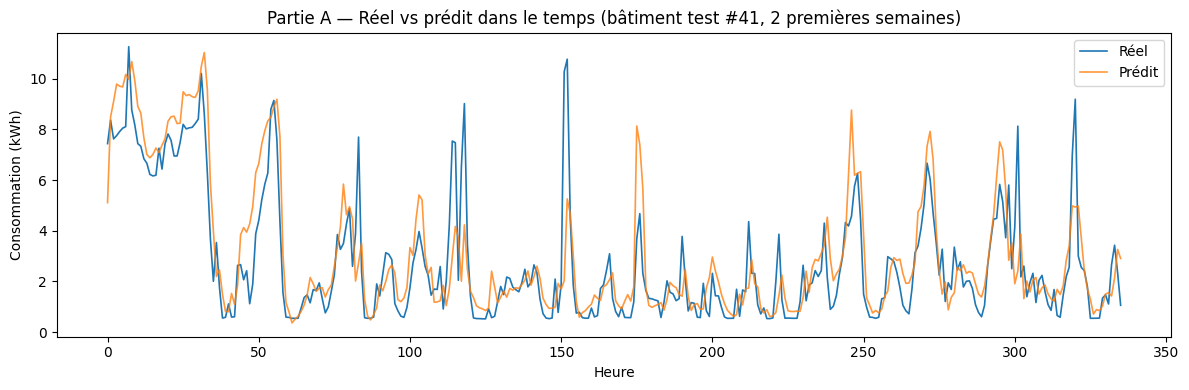

In [15]:
# Zoom temporel sur un bâtiment de test : le split par bâtiment fait que les fenêtres
# de chaque bâtiment se suivent dans Xa_test/ya_test/pred_test_a (ordre de test_idx)
n_windows_per_bldg_a = len(np.arange(0, hourly_all.shape[1] - LOOKBACK, WINDOW_STRIDE))
bldg_slice = slice(0, n_windows_per_bldg_a)
n_show = (24 * 14) // WINDOW_STRIDE  # deux semaines, ajusté au sous-échantillonnage (WINDOW_STRIDE)
x_hours = np.arange(n_show) * WINDOW_STRIDE  # ré-exprime l'axe x en heures réelles

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_hours, ya_test[bldg_slice][:n_show], label="Réel", linewidth=1.2)
ax.plot(x_hours, pred_test_a[bldg_slice][:n_show], label="Prédit", linewidth=1.2, alpha=0.8)
ax.set_xlabel("Heure")
ax.set_ylabel("Consommation (kWh)")
ax.set_title(f"Partie A — Réel vs prédit dans le temps (bâtiment test #{test_idx[0]}, 2 premières semaines)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_partieA_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
import gc

# Libère la RAM de la Partie A avant la Partie B : les tableaux de fenêtres (Xa_*), les tables
# statiques (Sa_*_table), les index de bâtiment (ba_*) et les Sequences Keras ne servent plus à
# rien une fois les métriques/figures de la Partie A calculées.
del Xa_train, Xa_val, Xa_test
del Sa_train_table, Sa_val_table, Sa_test_table
del ba_train, ba_val, ba_test
del train_seq_a, val_seq_a, test_seq_a
keras.backend.clear_session()
gc.collect()

# clear_session() remet à zéro le graphe Keras mais décale le flux aléatoire global de TF (l'init
# de model_b dépendrait alors du nombre d'epochs qu'a fait model_a) -> on reseed explicitement pour
# que la Partie B soit reproductible indépendamment de ce qui s'est passé en Partie A
tf.random.set_seed(RANDOM_STATE)

## Partie B — Extrapolation du total annuel (90 premiers jours observés)

À partir des 90 premiers jours de l'année (consommation + météo, au pas **journalier** — la
séquence est donc bien plus courte que pour la Parie A, 90 pas au lieu de 24), on extrapole la
consommation électrique totale de l'année complète.

 Ici, une seule observation par bâtiment (donc 70 exemples d'entraînement seulement) : le
réseau est volontairement gardé petit (peu d'unités, dropout) pour limiter le sur-apprentissage,
mais les résultats restent à interpréter avec prudence — cf. avertissement en introduction.

In [17]:
K_DAYS = 90

X_seq_annual = daily_all[:, :K_DAYS, :]          # (100, 90, n_seq_features)
y_annual = daily_all[:, :, 0].sum(axis=1)        # consommation totale sur les 365 jours

Xb_train, Xb_val, Xb_test = X_seq_annual[train_idx], X_seq_annual[val_idx], X_seq_annual[test_idx]
Sb_train, Sb_val, Sb_test = static_all[train_idx], static_all[val_idx], static_all[test_idx]
yb_train, yb_val, yb_test = y_annual[train_idx], y_annual[val_idx], y_annual[test_idx]

print(f"Train : {Xb_train.shape[0]} bâtiments  |  Val : {Xb_val.shape[0]}  |  Test : {Xb_test.shape[0]}")

Train : 70 bâtiments  |  Val : 15  |  Test : 15


In [18]:
seq_scaler_b = StandardScaler().fit(Xb_train.reshape(-1, N_SEQ_FEATURES))
Xb_train_sc = seq_scaler_b.transform(Xb_train.reshape(-1, N_SEQ_FEATURES)).reshape(Xb_train.shape).astype("float32")
Xb_val_sc = seq_scaler_b.transform(Xb_val.reshape(-1, N_SEQ_FEATURES)).reshape(Xb_val.shape).astype("float32")
Xb_test_sc = seq_scaler_b.transform(Xb_test.reshape(-1, N_SEQ_FEATURES)).reshape(Xb_test.shape).astype("float32")

static_scaler_b = StandardScaler().fit(Sb_train)
Sb_train_sc = static_scaler_b.transform(Sb_train).astype("float32")
Sb_val_sc = static_scaler_b.transform(Sb_val).astype("float32")
Sb_test_sc = static_scaler_b.transform(Sb_test).astype("float32")

y_scaler_b = StandardScaler().fit(yb_train.reshape(-1, 1))
yb_train_sc = y_scaler_b.transform(yb_train.reshape(-1, 1)).astype("float32").ravel()
yb_val_sc = y_scaler_b.transform(yb_val.reshape(-1, 1)).astype("float32").ravel()

In [19]:
model_b = build_hybrid_model(
    K_DAYS, N_SEQ_FEATURES, N_STATIC_FEATURES,
    rnn_type="GRU", rnn_units=16, static_units=(16,), dropout=0.3,
)
model_b.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
model_b.summary()

early_stop_b = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history_b = model_b.fit(
    [Xb_train_sc, Sb_train_sc], yb_train_sc,
    validation_data=([Xb_val_sc, Sb_val_sc], yb_val_sc),
    epochs=150, batch_size=8, callbacks=[early_stop_b], verbose=0,
)
print(f"Arrêt à l'epoch {len(history_b.history['loss'])} (early stopping)")

Model: "hybrid_GRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 90, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 85)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 16)        │      1,248 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      1,376 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        264 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          9 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,897 (11.32 KB)

 Trainable params: 2,897 (11.32 KB)

 Non-trainable params: 0 (0.00 B)

Arrêt à l'epoch 150 (early stopping)


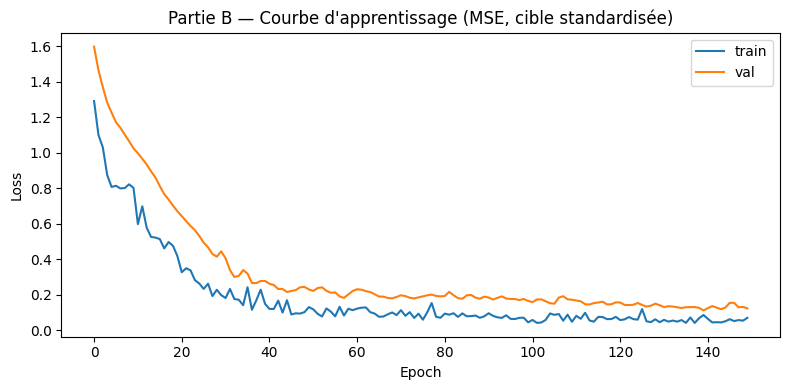

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(history_b.history["loss"], label="train")
plt.plot(history_b.history["val_loss"], label="val")
plt.title("Partie B — Courbe d'apprentissage (MSE, cible standardisée)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_loss_modele_b_extrapolationannuelle.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
pred_test_b_sc = model_b.predict([Xb_test_sc, Sb_test_sc], verbose=0)
pred_test_b = y_scaler_b.inverse_transform(pred_test_b_sc).ravel()

dummy_pred_b = np.full_like(yb_test, yb_train.mean())

df_metrics_b = pd.DataFrame([
    metrics(yb_test, dummy_pred_b, "Dummy (moyenne du train)"),
    metrics(yb_test, pred_test_b, f"Hybride GRU+MLP ({K_DAYS}j observés)"),
]).set_index("Modèle")

df_metrics_b.round(4)

,RMSE,MAE,R2
Modèle,,,
Dummy (moyenne du train),12636.5597,9516.2754,-0.0007
Hybride GRU+MLP (90j observés),5606.8501,4154.5483,0.8030


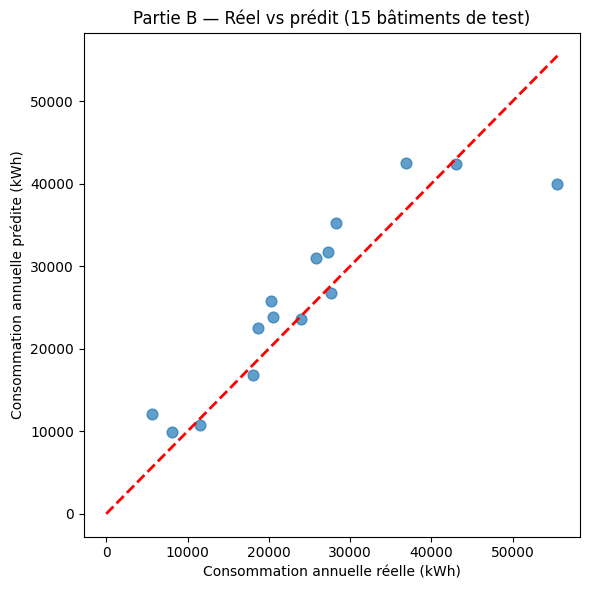

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yb_test, pred_test_b, s=60, alpha=0.7)
lim = [0, max(yb_test.max(), pred_test_b.max())]
ax.plot(lim, lim, "r--", linewidth=2)
ax.set_xlabel("Consommation annuelle réelle (kWh)")
ax.set_ylabel("Consommation annuelle prédite (kWh)")
ax.set_title(f"Partie B — Réel vs prédit ({len(yb_test)} bâtiments de test)")
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_tacheB_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

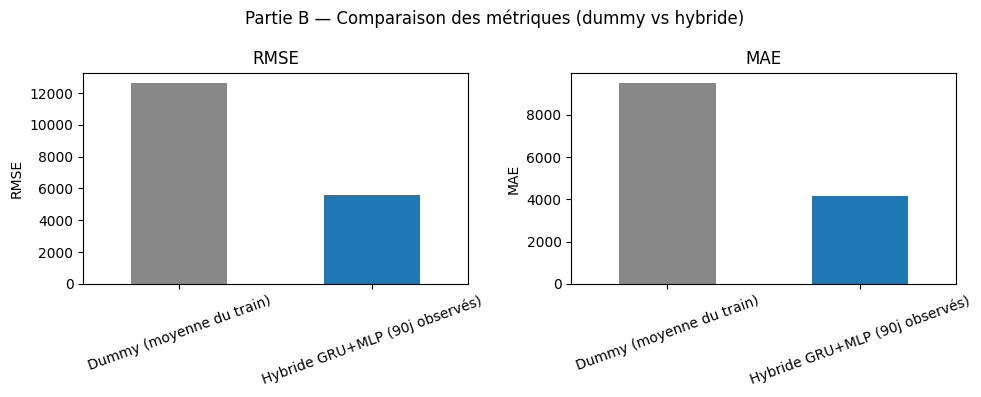

In [23]:
plot_metrics_bar(
    df_metrics_b,
    "Partie B — Comparaison des métriques (dummy vs hybride)",
    "rnn_mlp_partieB_metrics_bar.png",
)

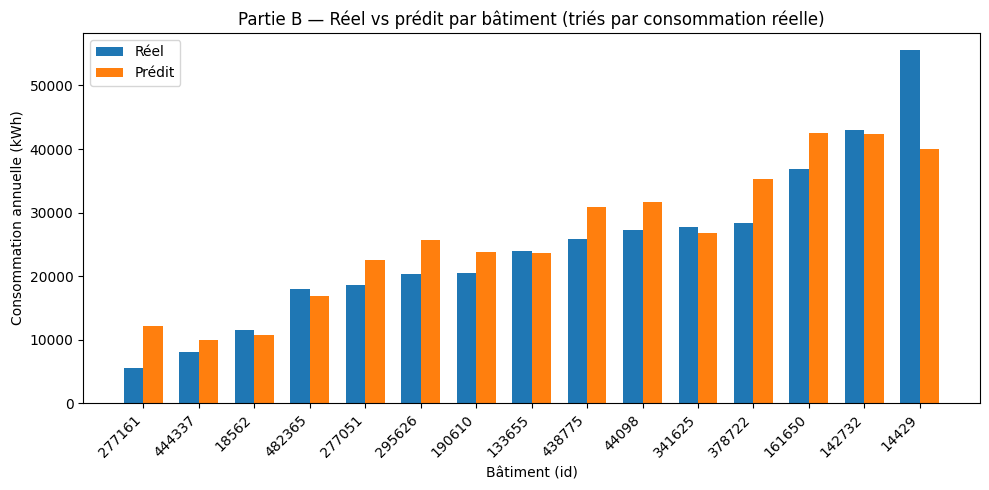

In [24]:
# Réel vs prédit par bâtiment de test, triés par consommation réelle croissante
order = np.argsort(yb_test)
bldg_labels = [str(b) for b in np.array(bldg_ids)[test_idx][order]]

x = np.arange(len(yb_test))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, yb_test[order], width, label="Réel")
ax.bar(x + width / 2, pred_test_b[order], width, label="Prédit")
ax.set_xticks(x)
ax.set_xticklabels(bldg_labels, rotation=45, ha="right")
ax.set_xlabel("Bâtiment (id)")
ax.set_ylabel("Consommation annuelle (kWh)")
ax.set_title("Partie B — Réel vs prédit par bâtiment (triés par consommation réelle)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "rnn_mlp_partieB_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Synthèse

- **Architecture hybride** (RNN/LSTM/GRU + MLP) validée sur deux parties de nature différente
  (prévision court terme abondante en données, extrapolation annuelle rare en données), avec le
  même bloc `build_hybrid_model` réutilisé — seul `rnn_type` change pour comparer
  SimpleRNN/LSTM/GRU si besoin.
- **Partie A** : la fenêtre de 24h + météo + métadonnées bat la baseline de persistance — le
  modèle apporte une information réelle au-delà de la simple autocorrélation horaire. Les
  résidus sont globalement centrés sur zéro et le suivi temporel sur un bâtiment de test
  confirme que le modèle capture bien la dynamique journalière.
- **Partie B** : le signal des 90 premiers jours + météo + métadonnées permet d'extrapoler le
  total annuel nettement mieux qu'une baseline naïve, mais **sur seulement 15 bâtiments de
  test** — à confirmer sur un échantillon de bâtiments tout-électriques plus large avant toute
  conclusion définitive.
- **Limite principale** : la Partie B souffre d'un déséquilibre structurel entre le nombre de
  paramètres du réseau et le nombre d'exemples d'entraînement (70). Prochaine étape naturelle :
  étendre l'échantillon tout-électrique au-delà de 100 bâtiments (cf. pipeline de téléchargement
  déjà en place dans `timeseries_clustering_multi.ipynb`) pour fiabiliser ces résultats.